# Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)



# Read dataset

In [ ]:
df=pd.read_csv('/content/dataset.csv')


In [ ]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,94.689486,0.212096,2.379196,1.0,0.0,0.0,0.0,0
1,2.148094,3.631258,0.867552,1.0,1.0,0.0,1.0,0
2,8.201513,0.196793,0.568646,1.0,0.0,0.0,1.0,0
3,1.813192,0.613588,0.749469,0.0,1.0,0.0,1.0,0
4,26.211924,4.871637,1.610984,1.0,0.0,1.0,1.0,0


In [ ]:
df.tail()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
99995,12.621258,0.487069,5.275131,1.0,0.0,0.0,1.0,1
99996,19.296230,4.696662,0.825513,1.0,1.0,0.0,1.0,0
99997,0.492862,0.110619,0.258427,0.0,0.0,0.0,0.0,0
99998,30.151727,0.832781,5.357237,1.0,0.0,0.0,1.0,1
99999,2.722695,3.671025,0.084158,1.0,0.0,0.0,0.0,0


# Sanity check for data

In [ ]:
df.shape

(100000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              99997 non-null   float64
 1   distance_from_last_transaction  99998 non-null   float64
 2   ratio_to_median_purchase_price  99997 non-null   float64
 3   repeat_retailer                 99997 non-null   float64
 4   used_chip                       99998 non-null   float64
 5   used_pin_number                 99997 non-null   float64
 6   online_order                    99995 non-null   float64
 7   fraud                           100000 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 6.1 MB


In [ ]:
#finding missing value
df.isnull().sum()

,0
distance_from_home,3
distance_from_last_transaction,2
ratio_to_median_purchase_price,3
repeat_retailer,3
used_chip,2
used_pin_number,3
online_order,5
fraud,0


In [ ]:
#finding duplicates
df.duplicated().sum()

np.int64(0)

# **Exploratory data analysis**

In [ ]:
#descriptive statistics
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,99997.000000,99998.000000,99997.000000,99997.000000,99998.000000,99997.000000,99995.000000,100000.000000
mean,26.590858,5.014177,1.840099,0.880566,0.349027,0.101293,0.651043,0.087400
std,64.651516,27.936887,2.853853,0.324300,0.476665,0.301718,0.476643,0.282422
min,0.024602,0.000434,0.007427,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.862822,0.292248,0.476110,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.927322,0.991687,1.003492,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.748499,3.349869,2.108197,1.000000,1.000000,0.000000,1.000000,0.000000
max,5797.972589,4968.315477,126.294930,1.000000,1.000000,1.000000,1.000000,1.000000


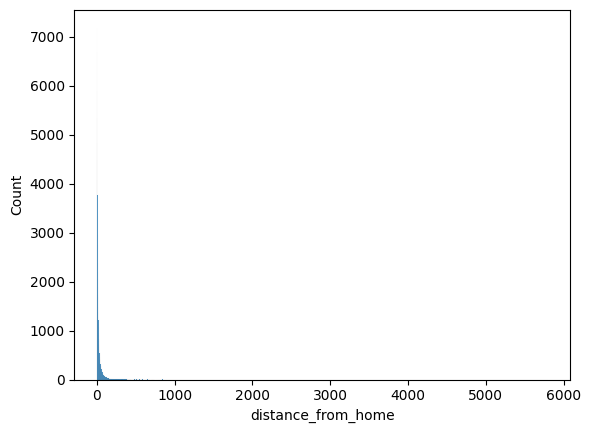

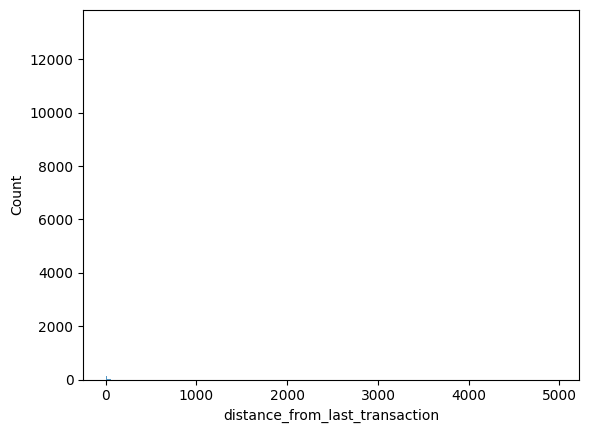

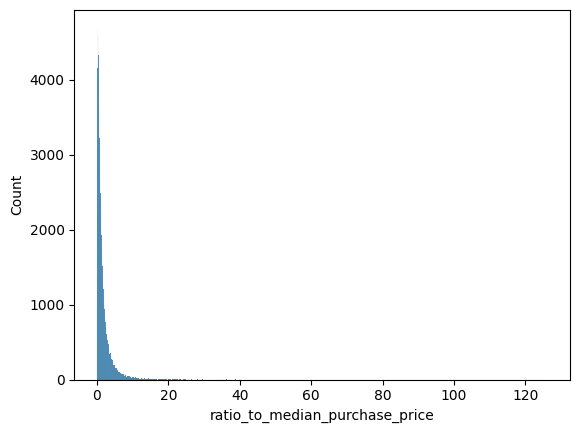

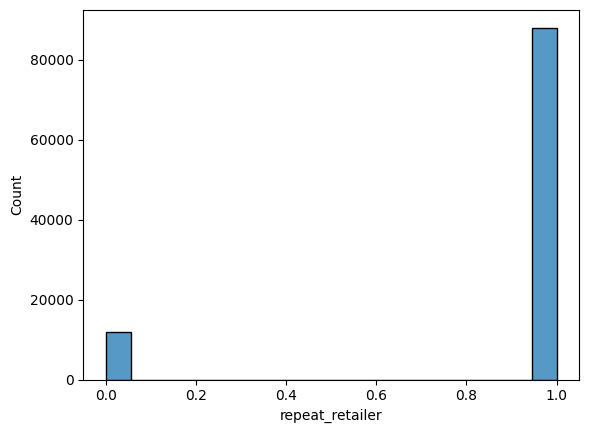

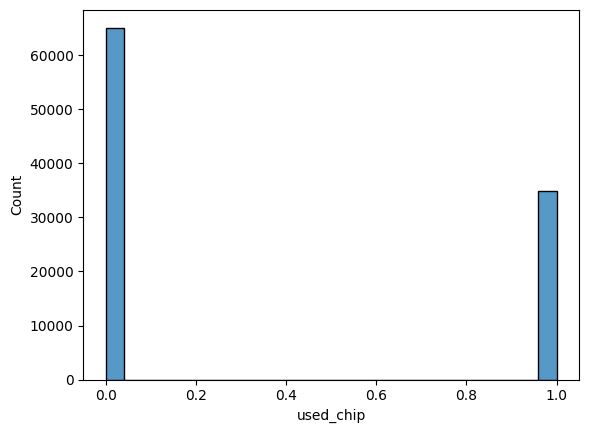

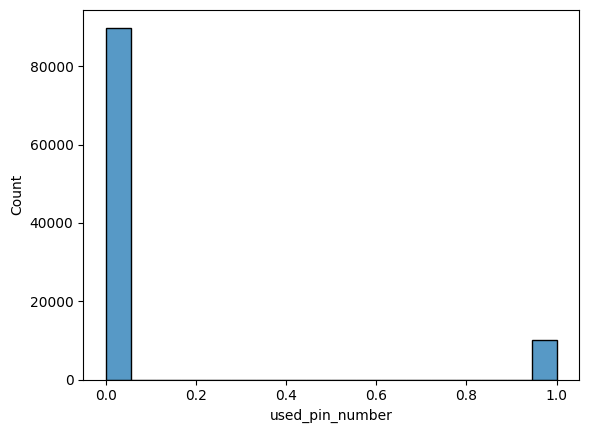

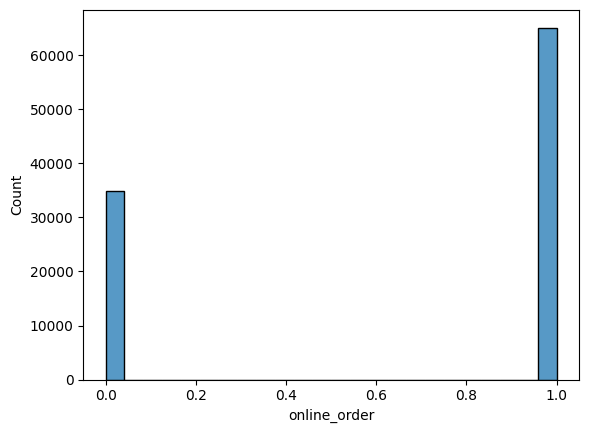

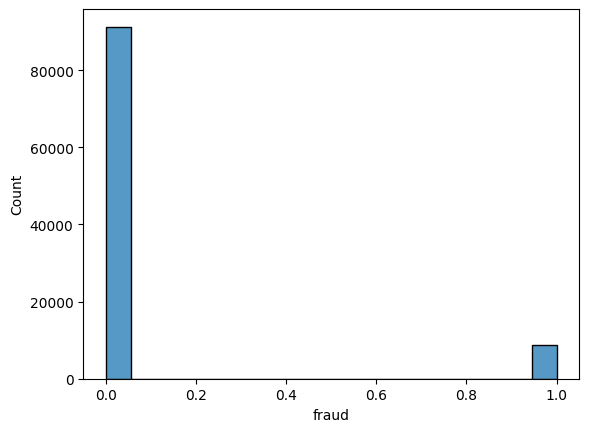

In [ ]:
#histogram to understand the distribution
for i in df.columns:
  sns.histplot(df[i])
  plt.show()

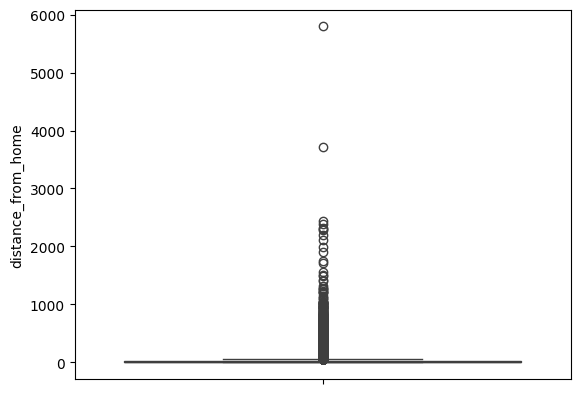

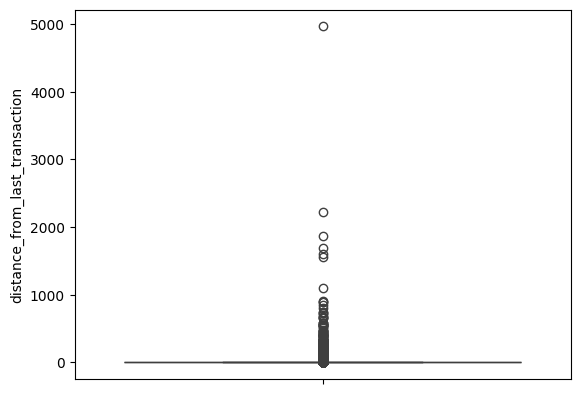

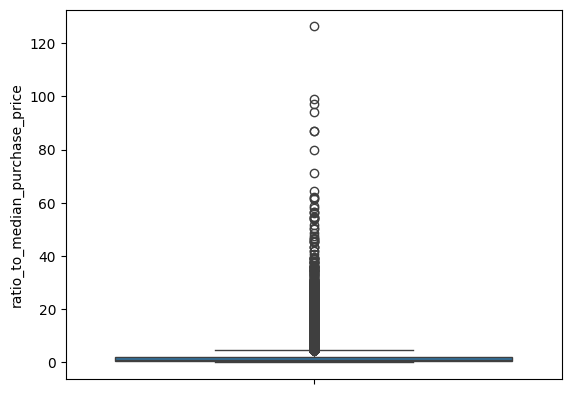

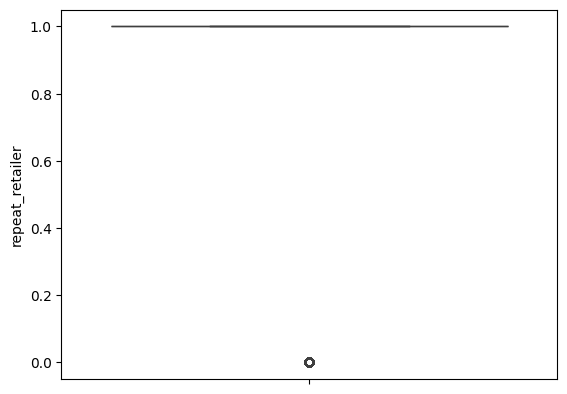

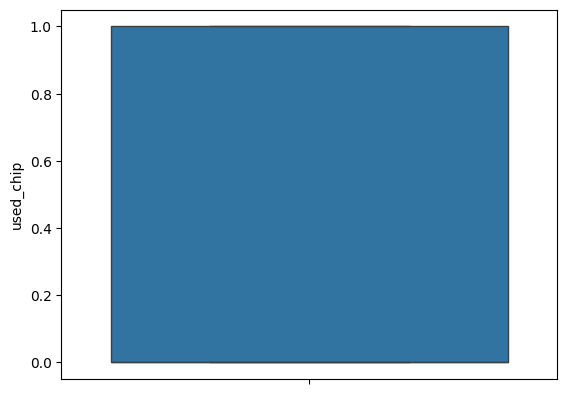

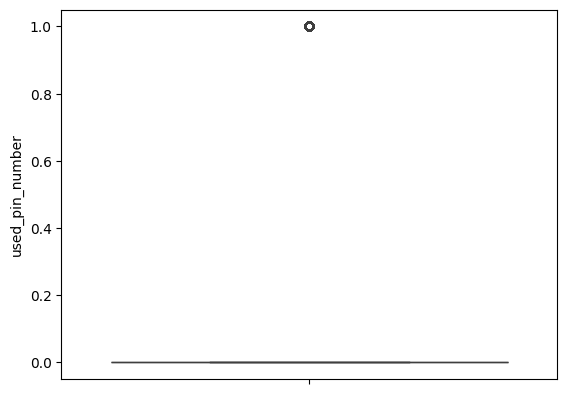

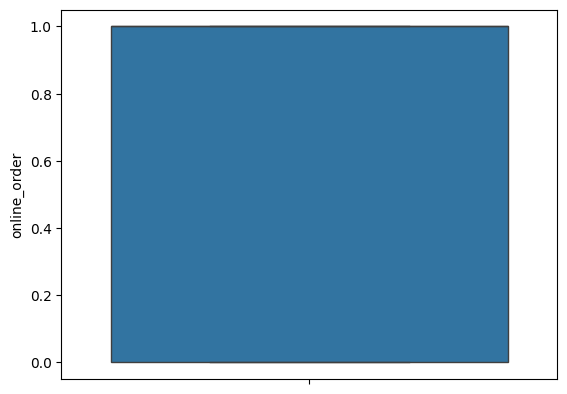

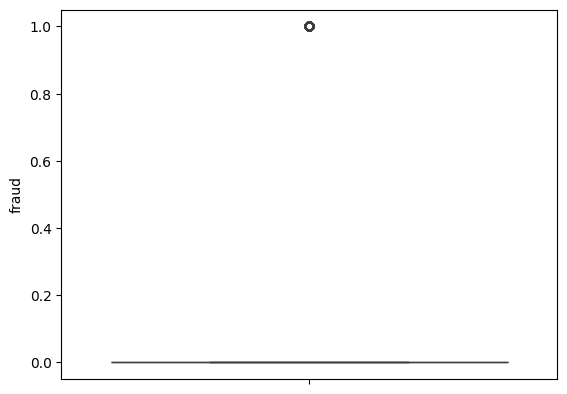

In [ ]:
#to find the outliers use boxplot
for i in df.columns:
  sns.boxplot(df[i])
  plt.show()

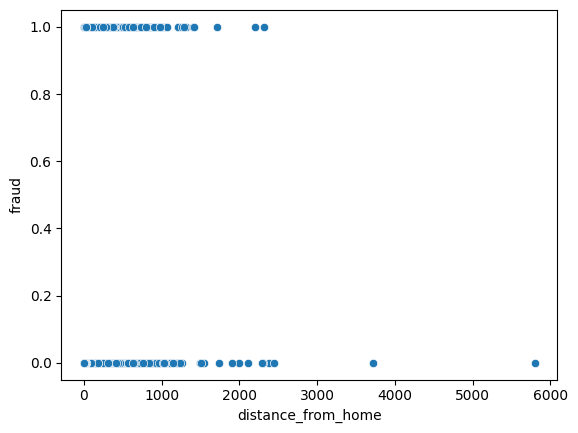

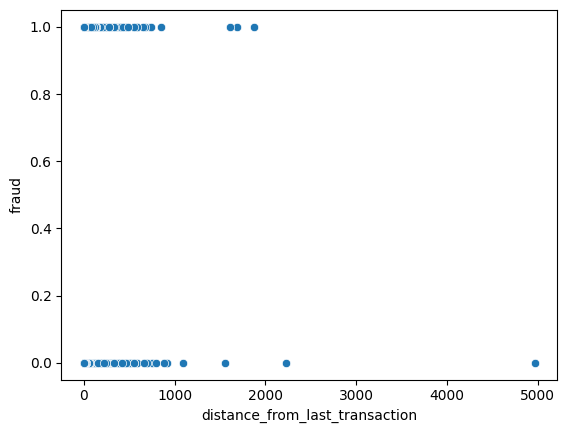

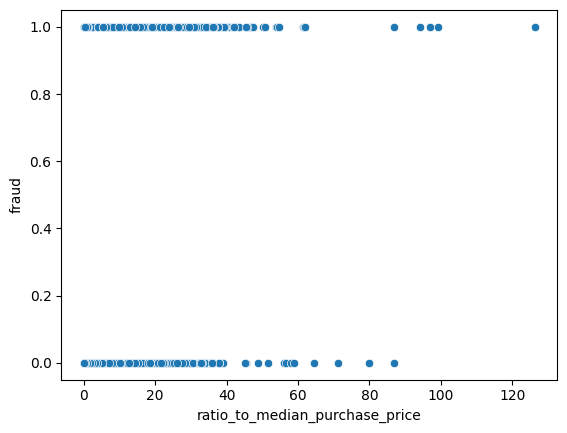

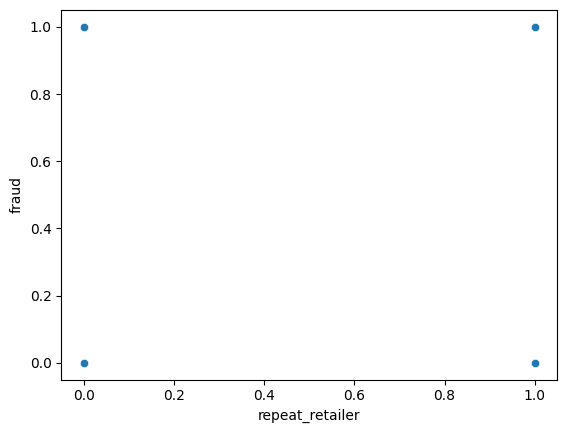

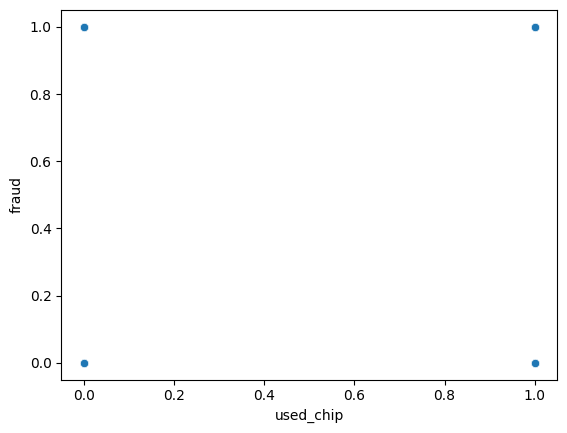

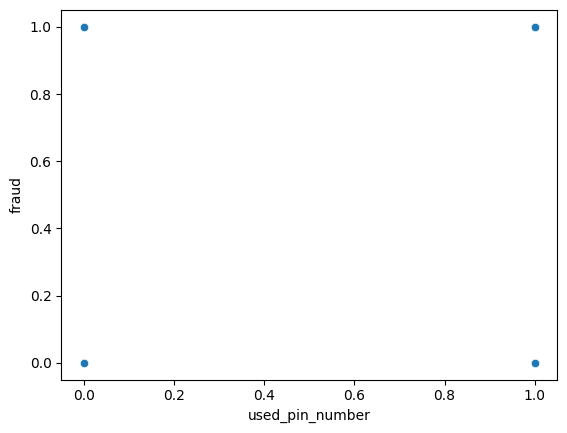

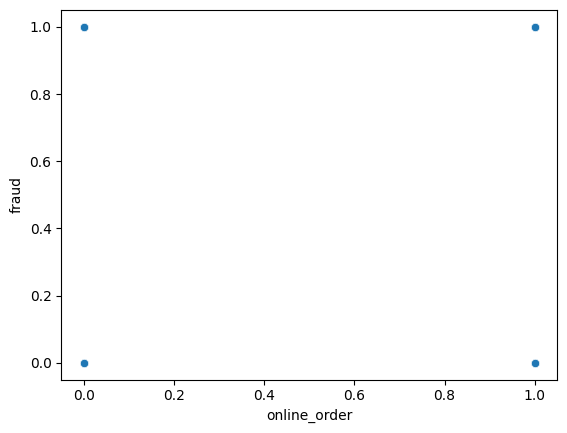

In [ ]:
#scatter plot to understand the relationship
for i in ['distance_from_home', 'distance_from_last_transaction',	'ratio_to_median_purchase_price',	'repeat_retailer', 'used_chip','used_pin_number',	'online_order']:
  sns.scatterplot(x=i,y='fraud', data=df)
  plt.show()

In [ ]:
#to see correlation between columns
df.corr()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,-0.000475,-0.003086,0.145195,-0.000548,-0.001548,-0.005067,0.185879
distance_from_last_transaction,-0.000475,1.000000,0.007598,0.003769,0.005187,-0.001817,-0.003318,0.086269
ratio_to_median_purchase_price,-0.003086,0.007598,1.000000,0.001662,0.000554,-0.001035,-0.002415,0.458613
repeat_retailer,0.145195,0.003769,0.001662,1.000000,-0.004105,-0.001975,0.001700,-0.002663
used_chip,-0.000548,0.005187,0.000554,-0.004105,1.000000,0.001718,0.000817,-0.059316
used_pin_number,-0.001548,-0.001817,-0.001035,-0.001975,0.001718,1.000000,0.002552,-0.100611
online_order,-0.005067,-0.003318,-0.002415,0.001700,0.000817,0.002552,1.000000,0.190824
fraud,0.185879,0.086269,0.458613,-0.002663,-0.059316,-0.100611,0.190824,1.000000


<Axes: >

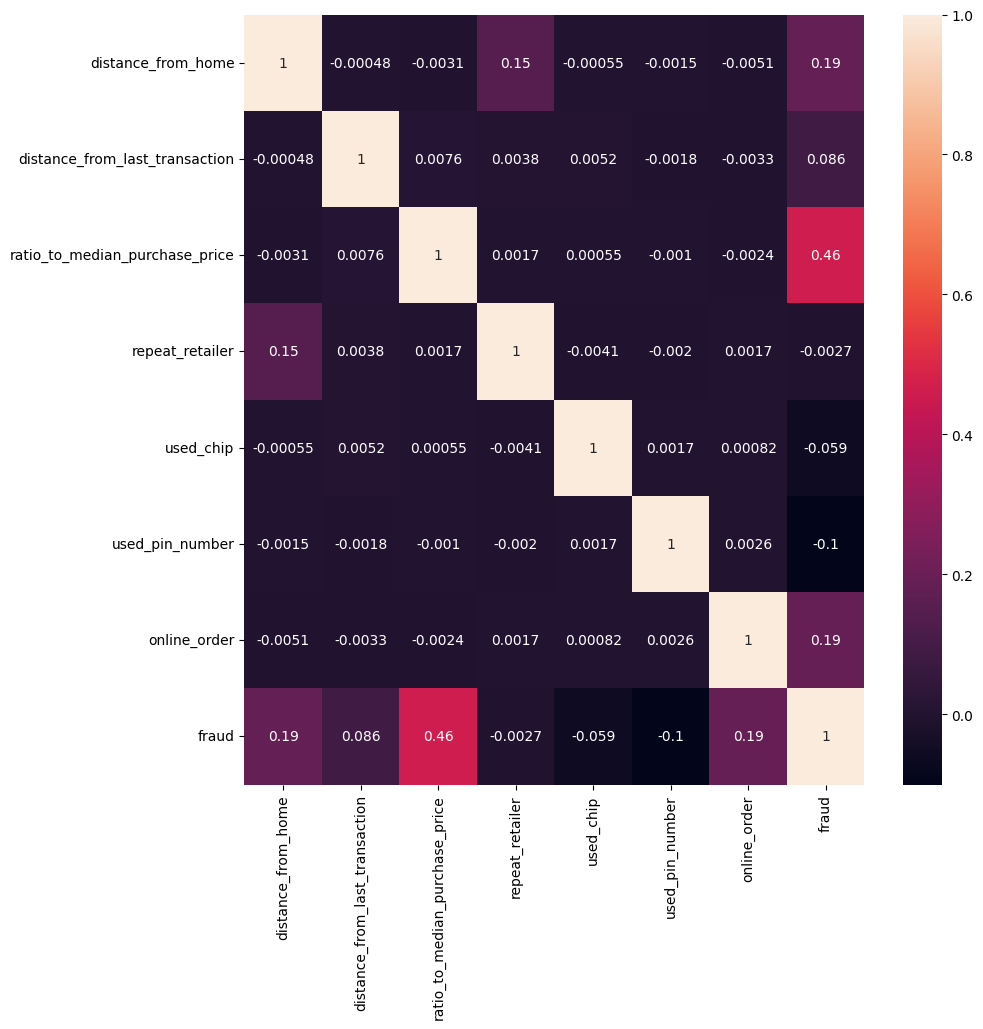

In [ ]:
#correlation between columns with heatmap to interpret the relatioin and multicolliniarity
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

# **Missing value treatments**

In [ ]:
#for continuous data replace the missing values with the mean or median
#if discrete so replace it with mode
for i in ['distance_from_home','distance_from_last_transaction','ratio_to_median_purchase_price','used_pin_number']:
    df[i].fillna(df[i].median(),inplace=True)

/tmp/ipython-input-2681850387.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)


In [ ]:
#if discrete so replace it with mode
for i in ['repeat_retailer','used_chip','online_order']:
     df[i].fillna(df[i].mode()[0],inplace=True)   #mode()[0] is present here because multiple mode values can be present so we need to take the first one

/tmp/ipython-input-1467385866.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0],inplace=True)   #mode()[0] is present here because multiple mode values can be present so we need to take the first one


In [ ]:
#check the number of missing values
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


# **Statistical tests**

In [ ]:
#Features with low p-value are important
from sklearn.feature_selection import chi2

X = df.drop(columns=['fraud'])
y = df['fraud']

chi_scores, p_values = chi2(X, y)
pd.Series(p_values, index=X.columns).sort_values(ascending=False)


,0
repeat_retailer,7.729310e-01
used_chip,9.846627e-52
used_pin_number,7.776727e-200
online_order,2.700668e-278
ratio_to_median_purchase_price,0.000000e+00
distance_from_home,0.000000e+00
distance_from_last_transaction,0.000000e+00


In [ ]:
#Features with high chi-scores are important
pd.Series(chi_scores, index=X.columns).sort_values(ascending=False)

,0
distance_from_home,543105.524415
distance_from_last_transaction,115843.034644
ratio_to_median_purchase_price,93091.052813
online_order,1270.649876
used_pin_number,909.664914
used_chip,229.000644
repeat_retailer,0.083257


# **Feature selection**

In [ ]:
#Feature selection using correlation analysis, Chi-Square tests, and statistical significance (p-values).

final_df = df[
    ['ratio_to_median_purchase_price',
     'distance_from_home',
     'distance_from_last_transaction',
     'online_order',
     'fraud']]

final_df.head()


,ratio_to_median_purchase_price,distance_from_home,distance_from_last_transaction,online_order,fraud
0,2.379196,94.689486,0.212096,0.0,0
1,0.867552,2.148094,3.631258,1.0,0
2,0.568646,8.201513,0.196793,1.0,0
3,0.749469,1.813192,0.613588,1.0,0
4,1.610984,26.211924,4.871637,1.0,0


# **Train–Test Split and Feature Normalization**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Split FIRST
X = final_df.drop(columns=['fraud'])
y = final_df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale AFTER split
scaler = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# **Classical Machine Learning Baselines for Comparison**

# **1. Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

# **2. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

# **Baseline Model Evaluation (Accuracy and AUC)**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic Regression evaluation
y_pred_lr=lr.predict(X_test_scaled)
y_pred_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_prob_lr)

# Random Forest evaluation
y_pred_rf=rf.predict(X_test_scaled)
y_pred_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

print("LR Accuracy:", acc_lr)
print("RF Accuracy:", acc_rf)

print("LR AUC:", auc_lr)
print("RF AUC:", auc_rf)


LR Accuracy: 0.9378
RF Accuracy: 0.97425
LR AUC: 0.9522310899379196
RF AUC: 0.992567928357182


# **Quantum Machine Learning Classifier**

In [ ]:
!pip install qiskit qiskit-aer
!pip install pylatexenc


In [ ]:
!pip install -U pylatexenc matplotlib "qiskit[visualization]"


# **Import qiskit libraries**

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import circuit_drawer
from qiskit.circuit import ParameterVector
from qiskit import transpile
from qiskit.quantum_info import Statevector


# **Feature Encoding**

In [ ]:
# x: one data sample (array of length = n_qubits)
# Initialize all qubits in the |0⟩ state (default starting state of a quantum circuit)
def ry_feature_map(x):
    qc = QuantumCircuit(len(x))

    # Encode classical features into qubits using RY rotations
    # rotates qubit i by angle x[i] , this converts numbers → quantum state
    for i in range(len(x)):
        qc.ry(x[i], i)

    return qc


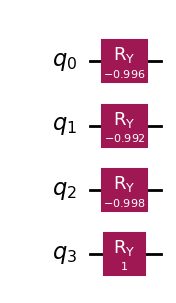

In [ ]:

# Select one scaled training sample
# X_train_scaled[0] means:
# [0] means : first data sample (first row)
sample = X_train_scaled[0]

# Apply quantum feature mapping using RY rotations
# ry_feature_map(sample):
# - Creates a quantum circuit
qc = ry_feature_map(sample)

# Visualize the quantum circuit
qc.draw('mpl')


# **Variational quantum circuit(VQC) Implementation**

In [ ]:
def vqc_with_data_reuploading(n_qubits, n_layers):
    """
    Creates a Variational Quantum Circuit (VQC) with data re-uploading.

    n_qubits  : Number of qubits (equal to number of input features)
    n_layers  : Number of variational layers
    """

    # Initialize a quantum circuit with n_qubits
    # All qubits start in the |0> state (|000...0>)
    qc = QuantumCircuit(n_qubits)

    # Define parameter vector for classical input features
    # These parameters will be replaced by scaled classical data
    x = ParameterVector('x', n_qubits)

    # Define trainable parameters for the variational ansatz
    # These parameters are optimized during training
    theta = ParameterVector('θ', n_qubits * n_layers)

    # Index to track usage of trainable parameters
    param_idx = 0

    # Loop over each variational layer
    for layer in range(n_layers):

        # -------------------------------
        # Data Encoding (Data Re-uploading)
        # -------------------------------
        # Classical data is encoded multiple times across layers
        # This improves the expressive power of the quantum model
        for i in range(n_qubits):
            qc.ry(x[i], i)  # Encode feature x[i] using RY rotation

        # -------------------------------
        # Trainable Variational Ansatz
        # -------------------------------
        # Learnable quantum gates that act like weights in a neural network
        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)  # Trainable rotation
            param_idx += 1              # Move to next parameter

        # -------------------------------
        # Entanglement Layer
        # -------------------------------
        # CNOT gates create correlations between qubits
        # This allows interaction between different features
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)

    # Return the constructed parameterized quantum circuit
    return qc


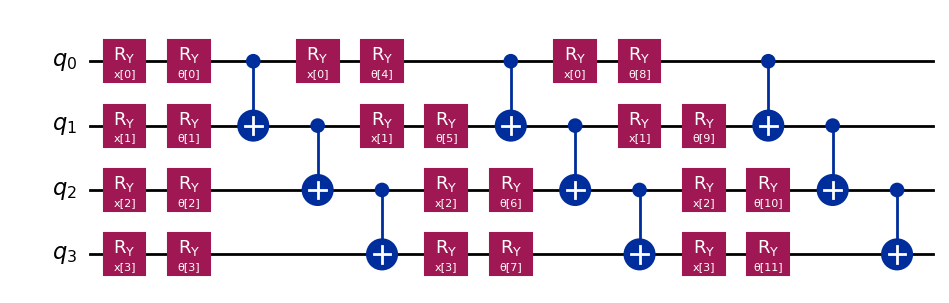

In [ ]:
# Number of qubits is set equal to the number of input features
# Each feature is encoded into one qubit
n_qubits = X_train_scaled.shape[1]

# Number of variational layers
# Kept small to reduce circuit depth and make it hardware-friendly
n_layers = 3

# Construct the variational quantum circuit with data re-uploading
qc = vqc_with_data_reuploading(n_qubits, n_layers)

# Visualize the quantum circuit
# 'mpl' uses Matplotlib for a clear graphical representation
qc.draw('mpl')

# Explanation of the circuit structure:
# q0, q1, q2, ...       → individual qubits (one per feature)
# RY(x[i])             → encoding of classical feature values
# RY(θ[i])             → trainable parameters optimized during training
# CNOT gates           → create entanglement between neighboring qubits
# Repeated layers      → enable data re-uploading and improve expressivity


# **Hybrid Quantum–Classical Classification Architecture**

In [ ]:
# Function to compute expectation values from a quantum circuit
def get_expectation_values(qc, x, theta):
    """
    qc     : Parameterized quantum circuit (with data + trainable params)
    x      : One scaled data sample (feature vector)
    theta  : Trainable quantum parameters
    """

    # Dictionary to bind numerical values to circuit parameters
    param_dict = {}

    # Qiskit stores all parameters together
    # First part → data parameters (x)
    # Remaining → trainable parameters (theta)
    for i, p in enumerate(qc.parameters):
        if i < len(x):
            param_dict[p] = x[i]              # Data encoding
        else:
            param_dict[p] = theta[i - len(x)] # Trainable parameters

    # Assign parameters to the circuit
    # (assign_parameters is recommended in Qiskit 1.0+)
    bound_qc = qc.assign_parameters(param_dict)

    # Simulate circuit using statevector simulator
    state = Statevector.from_instruction(bound_qc)

    # Pauli-Z operator
    Z = np.array([[1, 0], [0, -1]])

    # Store expectation values for each qubit
    exp_vals = []

    for i in range(bound_qc.num_qubits):
        # Compute ⟨Z⟩ expectation value for qubit i
        exp_vals.append(state.expectation_value(Z, [i]).real)

    # Return classical feature vector
    return exp_vals


# **Quantum feature generation function**

In [ ]:

# Function to generate quantum features from classical data
# For each data sample:
# - Encode features into the quantum circuit
# - Measure expectation values
# - Store them as quantum-generated features
def generate_quantum_features(X, qc, theta):

    features = []

    # Loop over each data sample
    for x_sample in X:

        # Get expectation values for one sample
        exp_vals = get_expectation_values(qc, x_sample, theta)

        # Store the quantum features
        features.append(exp_vals)

    # Convert list to NumPy array for ML compatibility
    return np.array(features)


# **Circuit & initial parameters (seed-controlled)**


In [ ]:
# Initialize trainable quantum parameters (θ)
# Fix random seed for reproducibility
np.random.seed(42)

# Initialize θ values uniformly in [0, 2π]
theta_init = np.random.uniform(
    0, 2 * np.pi,
    size=n_qubits * n_layers
)

# **Loss function**

In [ ]:
from sklearn.metrics import log_loss
from sklearn.neural_network import MLPClassifier


# Loss function for optimizing quantum circuit parameters θ
def loss_function(theta):
    """
    theta : trainable quantum parameters
    returns : binary cross-entropy loss
    """


    # Generate quantum features using built-in function
    quantum_features_train = generate_quantum_features(
        X_train_scaled,   # scaled training data
        qc,         # parameterized quantum circuit
        theta             # trainable parameters
    )


    # Train classical neural network on quantum features
    clf = MLPClassifier(
        hidden_layer_sizes=(4,),      # small hidden layer
        activation='relu',
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=20,
        learning_rate_init=0.01,
        random_state=SEED
    )

    clf.fit(quantum_features_train, y_train)


    # Compute binary cross-entropy loss
    y_pred_prob = clf.predict_proba(quantum_features_train)[:, 1]
    loss = log_loss(y_train, y_pred_prob)

    return loss


# **Cobyla optimization**

In [ ]:
from scipy.optimize import minimize

# Optimization of quantum circuit parameters using COBYLA

# Initial values of trainable quantum parameters θ
theta0 = theta_init

# Run gradient-free optimization
result = minimize(
    loss_function,     # objective function (training loss)
    theta0,            # initial parameter values
    method="COBYLA",   # gradient-free optimizer (suitable for QML)
    options={
        "maxiter": 30, # number of optimization steps (kept small)
        "disp": True  # display optimization progress
    }
)

# Extract optimized quantum parameters
theta_opt = result.x

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 30   Least value of F = 0.09929906417188122
The corresponding X is:
[2.88429165 5.82492431 5.62033622 3.73182219 0.8665359  0.90369142
 0.44870253 5.31267335 3.68591663 4.18446149 0.1995829  6.07963181]



# **Comparative Analysis (Quantum vs Classical Models)**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score


# **Classical Baseline Model**

In [ ]:

# Classical baseline classifier
clf_classical = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    learning_rate_init=0.01,
    random_state=SEED
)

clf_classical.fit(X_train_scaled, y_train)

# Predict class labels and probabilities on test data
y_pred_classical = clf_classical.predict(X_test_scaled)
y_pred_classical_prob = clf_classical.predict_proba(X_test_scaled)[:, 1]

# Evaluate hybrid quantum-classical model performance
acc_classical = accuracy_score(y_test, y_pred_classical)
auc_classical = roc_auc_score(y_test, y_pred_classical_prob)


# **Quantum Model Evaluation**

In [ ]:
# Generate final quantum features using optimized quantum parameters (θ_opt)
X_train_scaled_q = []
X_test_scaled_q = []

# Encode training samples into quantum circuit and extract expectation values
for x in X_train_scaled:
    X_train_scaled_q.append(get_expectation_values(qc, x, theta_opt))

# Encode test samples using the same trained quantum circuit
for x in X_test_scaled:
    X_test_scaled_q.append(get_expectation_values(qc, x, theta_opt))

# Convert quantum features to NumPy arrays for sklearn compatibility
X_train_scaled_q = np.array(X_train_scaled_q)
X_test_scaled_q = np.array(X_test_scaled_q)

# Classical neural network trained on quantum-generated features (hybrid model)
clf_quantum = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    learning_rate_init=0.01,
    random_state=SEED
)

# Train the classifier using quantum features
clf_quantum.fit(X_train_scaled_q, y_train)

# Predict class labels and probabilities on test data
y_pred_quantum = clf_quantum.predict(X_test_scaled_q)
y_pred_quantum_prob = clf_quantum.predict_proba(X_test_scaled_q)[:, 1]

# Evaluate hybrid quantum-classical model performance
acc_quantum = accuracy_score(y_test, y_pred_quantum)
auc_quantum = roc_auc_score(y_test, y_pred_quantum_prob)


# **Results table**

In [ ]:

# =========================================
# Model Performance Comparison Table
# =========================================

# Create a pandas DataFrame to compare the performance
# of all trained models on the same test dataset
results = pd.DataFrame({

    # Names of models used in the study
    "Model": [
        "Logistic Regression",                 # Linear baseline model
        "Random Forest",                       # Tree-based ensemble model
        "Classical Neural Network (MLP)",      # Classical deep learning model
        "Quantum–Classical Hybrid"              # Hybrid quantum + classical model
    ],

    # Accuracy scores of each model
    "Accuracy": [
        acc_lr,                                # Accuracy of Logistic Regression
        acc_rf,                                # Accuracy of Random Forest
        acc_classical,                         # Accuracy of Classical MLP
        acc_quantum                            # Accuracy of Quantum-Hybrid model
    ],

    # AUC-ROC scores of each model
    "AUC-ROC": [
        auc_lr,                                # AUC of Logistic Regression
        auc_rf,                                # AUC of Random Forest
        auc_classical,                         # AUC of Classical MLP
        auc_quantum                            # AUC of Quantum-Hybrid model
    ]
})

# Display the comparison table
results


,Model,Accuracy,AUC-ROC
0,Logistic Regression,0.93780,0.952231
1,Random Forest,0.97425,0.992568
2,Classical Neural Network (MLP),0.96535,0.941301
3,Quantum–Classical Hybrid,0.96175,0.979559


# **ROC curve comparison**

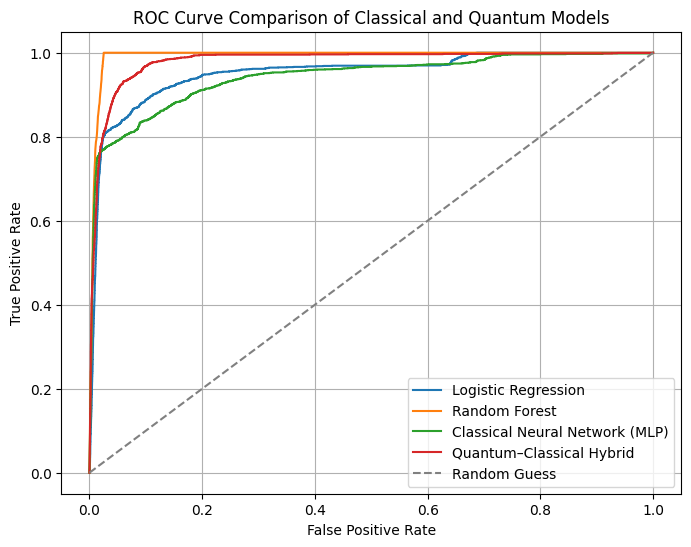

In [ ]:
# =========================================
# ROC Curve Comparison for All Models
# =========================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# -----------------------------------------
# Compute ROC curves
# -----------------------------------------

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Classical Neural Network (MLP)
fpr_c, tpr_c, _ = roc_curve(y_test, y_pred_classical_prob)

# Quantum–Classical Hybrid Model
fpr_q, tpr_q, _ = roc_curve(y_test, y_pred_quantum_prob)

# -----------------------------------------
# Plot ROC curves
# -----------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_c, tpr_c, label="Classical Neural Network (MLP)")
plt.plot(fpr_q, tpr_q, label="Quantum–Classical Hybrid")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")

# Axis labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classical and Quantum Models")

# Legend and grid
plt.legend()
plt.grid(True)

plt.show()
